In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Bank_Churn.csv")
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


#### Verificando valores vazios ou duplicadas

In [3]:
print(df.isnull().sum())
print(df.duplicated().sum())

CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64
0


### taxa de churn

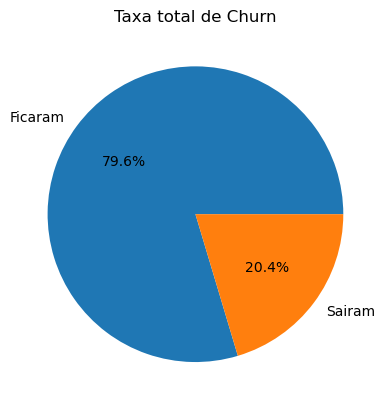

In [82]:
taxa_de_churn = df.groupby(['Exited']).size()
taxa_de_churn.index = ['Ficaram', 'Sairam']
taxa_de_churn.plot.pie(autopct='%1.1f%%')
plt.title('Taxa total de Churn')
plt.savefig('TAXA_DE_CHURN.png')
plt.show()

20.4% dos clientes sairam, agora o por que disso acontecer?

In [5]:
dados_churn = df[df['Exited']==1]
dados_churn

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
5,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
7,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
16,15737452,Romeo,653,Germany,Male,58,1,132602.88,1,1,0,5097.67,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9981,15672754,Burbidge,498,Germany,Male,42,3,152039.70,1,1,1,53445.17,1
9982,15768163,Griffin,655,Germany,Female,46,7,137145.12,1,1,0,115146.40,1
9991,15769959,Ajuluchukwu,597,France,Female,53,4,88381.21,1,1,0,69384.71,1
9997,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1


## VERIFICANDO DADOS PRINCIPAIS

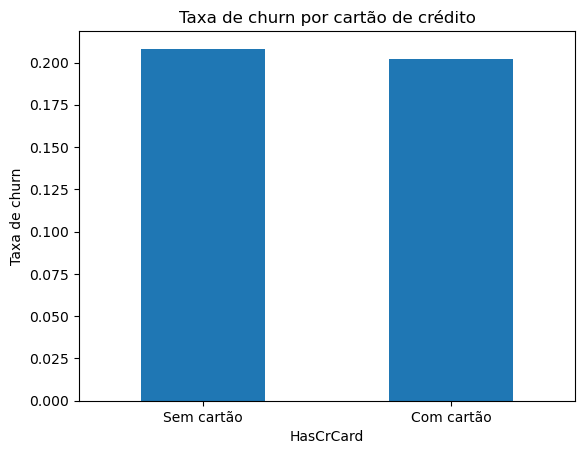

In [83]:
taxa = df.groupby('HasCrCard')['Exited'].mean()

taxa.plot(kind='bar')

plt.xticks([0,1], ['Sem cartão', 'Com cartão'], rotation=0)
plt.title('Taxa de churn por cartão de crédito')
plt.ylabel('Taxa de churn')
plt.savefig('TAXA_DE_CHURN_CARTAO.png')

plt.show()

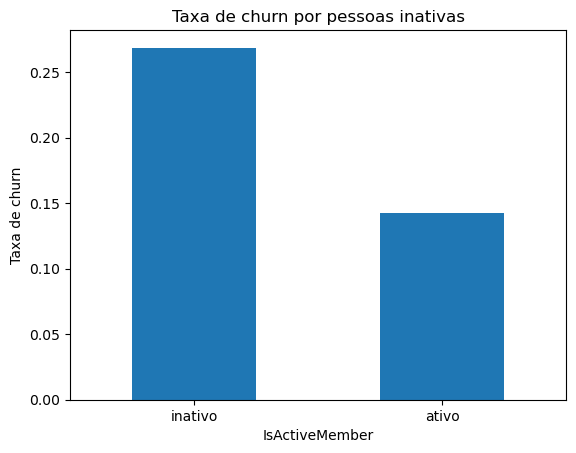

In [84]:
taxa = df.groupby('IsActiveMember')['Exited'].mean()

taxa.plot(kind='bar')

plt.xticks([0,1], ['inativo', 'ativo'], rotation=0)
plt.title('Taxa de churn por pessoas inativas')
plt.ylabel('Taxa de churn')
plt.savefig('TAXA_DE_CHURN_INATIVIDADE.png')



plt.show()

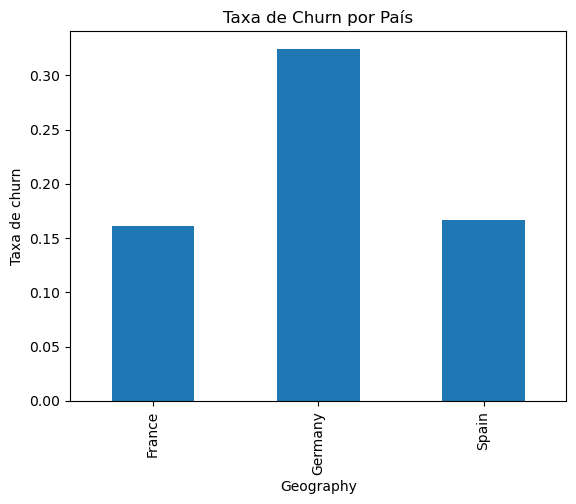

In [85]:
taxa_churn = df.groupby('Geography')['Exited'].mean()

taxa_churn.plot(kind='bar')

plt.title('Taxa de Churn por País')
plt.ylabel('Taxa de churn')
plt.savefig('TAXA_DE_CHURN_PAIS.png')

plt.show()

In [18]:
comparacao = df.groupby('Geography')['Exited'].agg(['count', 'sum', 'mean'])
comparacao.columns = ['Total Clientes', 'Churn', 'Taxa de Churn']

print(comparacao)

           Total Clientes  Churn  Taxa de Churn
Geography                                      
France               5014    810       0.161548
Germany              2509    814       0.324432
Spain                2477    413       0.166734


In [49]:
df.groupby('NumOfProducts')['Exited'].count()

NumOfProducts
1    5084
2    4590
3     266
4      60
Name: Exited, dtype: int64

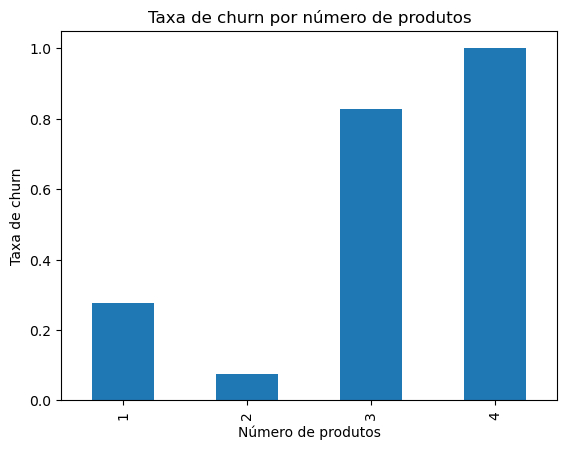

In [86]:
taxa_prod = df.groupby('NumOfProducts')['Exited'].mean()

taxa_prod.plot(kind='bar')

plt.title('Taxa de churn por número de produtos')
plt.xlabel('Número de produtos')
plt.ylabel('Taxa de churn')
plt.savefig('TAXA_DE_CHURN_PRODUTOS_QTD.png')

plt.show()

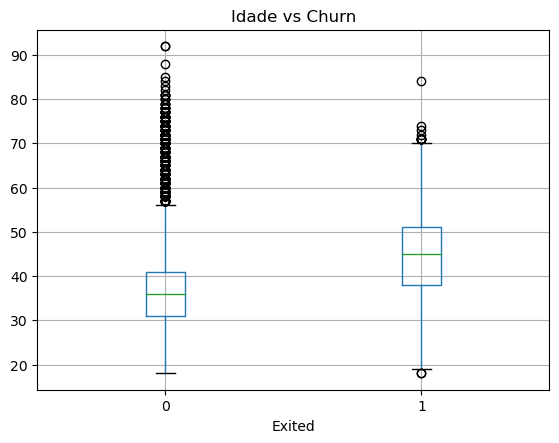

In [87]:
df.boxplot(column='Age', by='Exited')

plt.title('Idade vs Churn')
plt.suptitle('')

plt.savefig('TAXA_DE_CHURN_IDADE.png')
plt.show()

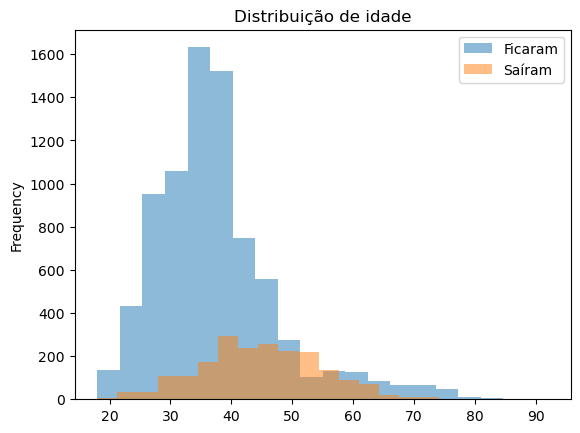

In [29]:
df[df['Exited'] == 0]['Age'].plot(kind='hist', alpha=0.5, bins=20)
df[df['Exited'] == 1]['Age'].plot(kind='hist', alpha=0.5, bins=20)

plt.legend(['Ficaram', 'Saíram'])
plt.title('Distribuição de idade')

plt.show()

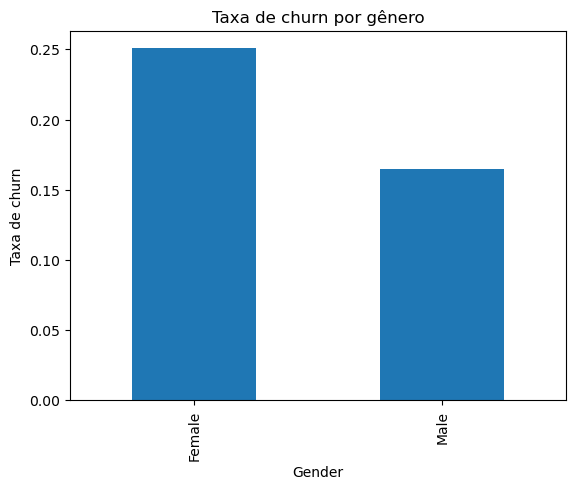

In [88]:
taxa_gender = df.groupby('Gender')['Exited'].mean()

taxa_gender.plot(kind='bar')

plt.title('Taxa de churn por gênero')
plt.ylabel('Taxa de churn')

plt.savefig('TAXA_DE_CHURN_GENERO.png')
plt.show()

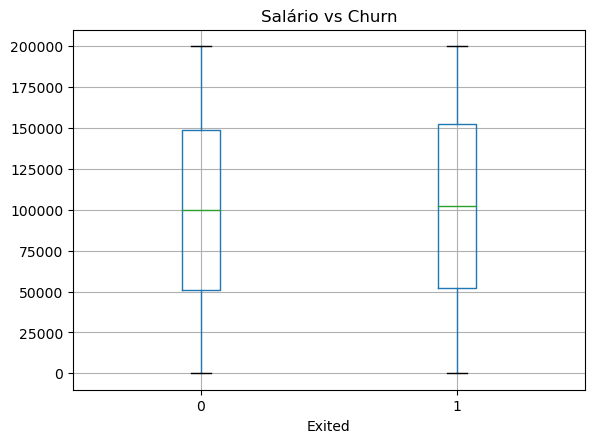

In [89]:
df.boxplot(column='EstimatedSalary', by='Exited')

plt.title('Salário vs Churn')
plt.suptitle('')
plt.savefig('TAXA_DE_CHURN_SALARIO.png')

plt.show()

Text(0.5, 0.98, '')

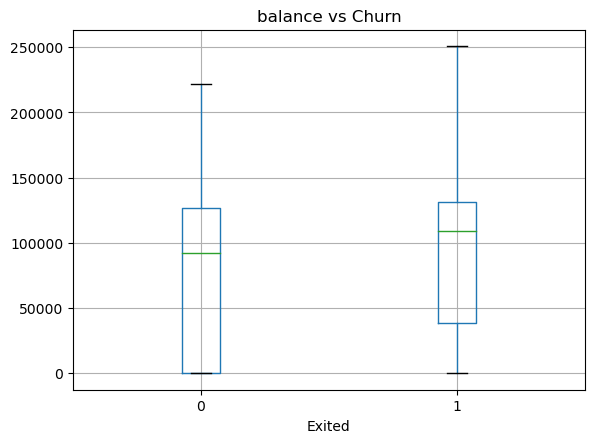

In [90]:
df.boxplot(column='Balance', by='Exited')
plt.title('balance vs Churn')

plt.savefig('TAXA_DE_CHURN_SALDO.png')
plt.suptitle('')  # remove título automático


### 💡 Insight principal (IMPORTANTE)

Clientes com saldo mais alto têm maior probabilidade de sair

Clientes com mais dinheiro:
- recebem mais ofertas de outros bancos
- são mais exigentes
- mudam por melhores benefícios

Clientes com saldo 0:
- muitas vezes são “inativos esquecidos”
- não necessariamente churn “ativo”

<Axes: xlabel='IsActiveMember'>

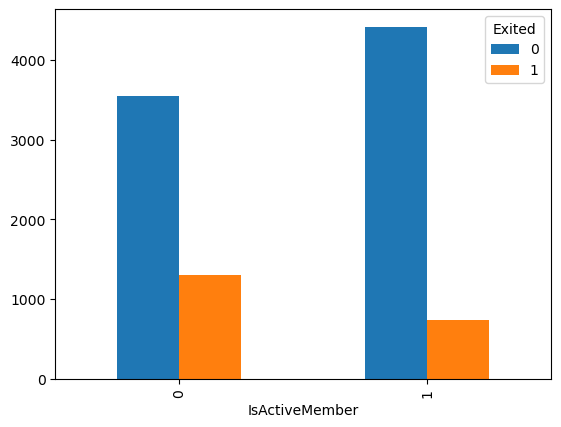

In [43]:
df.groupby(['IsActiveMember', 'Exited']).size().unstack().plot(kind='bar')

In [44]:
df[df['Balance'] > 100000].groupby('Exited').size()

Exited
0    3588
1    1211
dtype: int64

# DASHBOARD

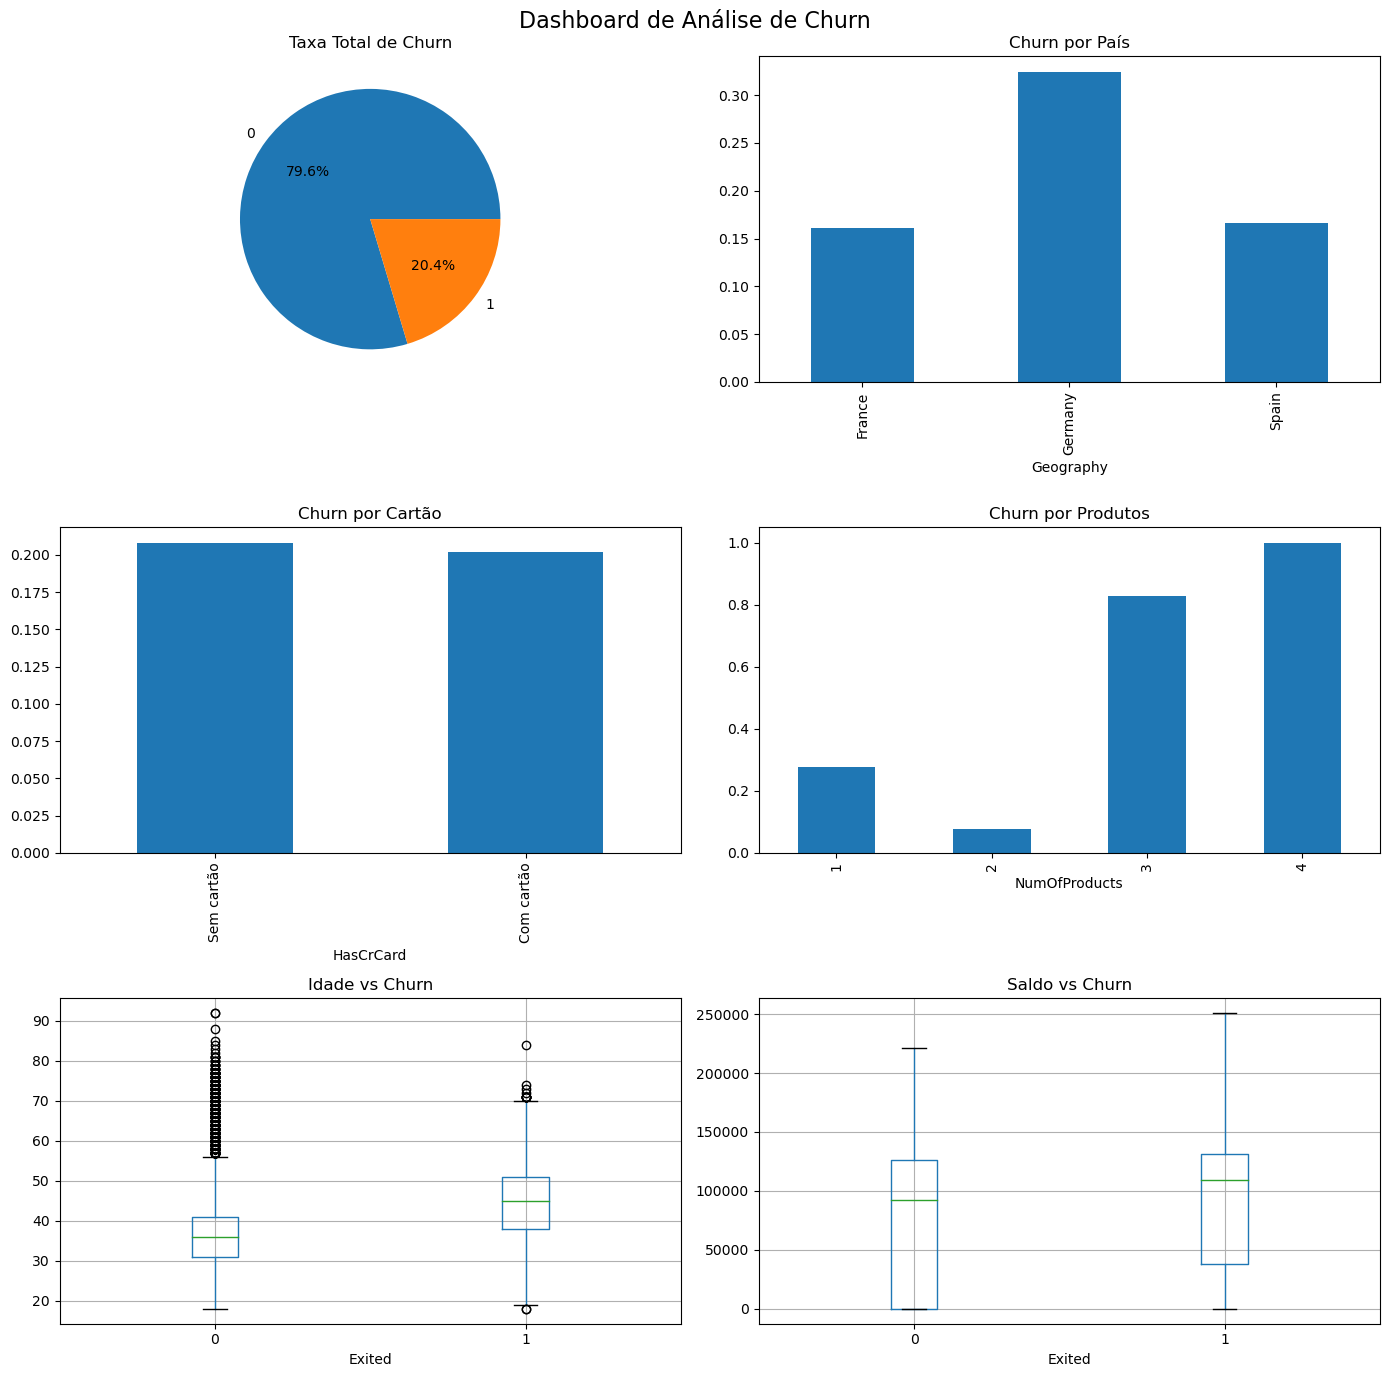

In [91]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 2, figsize=(14, 14))

# ---------------------------
# 1. CHURN TOTAL
# ---------------------------
df['Exited'].value_counts().plot.pie(
    autopct='%1.1f%%',
    ax=axs[0,0]
)
axs[0,0].set_title('Taxa Total de Churn')
axs[0,0].set_ylabel('')

# ---------------------------
# 2. CHURN POR PAÍS
# ---------------------------
df.groupby('Geography')['Exited'].mean().plot(
    kind='bar',
    ax=axs[0,1]
)
axs[0,1].set_title('Churn por País')

# ---------------------------
# 3. CARTÃO DE CRÉDITO
# ---------------------------
df.groupby('HasCrCard')['Exited'].mean().plot(
    kind='bar',
    ax=axs[1,0]
)
axs[1,0].set_title('Churn por Cartão')
axs[1,0].set_xticks([0,1])
axs[1,0].set_xticklabels(['Sem cartão', 'Com cartão'])

# ---------------------------
# 4. Nº DE PRODUTOS
# ---------------------------
df.groupby('NumOfProducts')['Exited'].mean().plot(
    kind='bar',
    ax=axs[1,1]
)
axs[1,1].set_title('Churn por Produtos')

# ---------------------------
# 5. IDADE (BOXPLOT)
# ---------------------------
df.boxplot(column='Age', by='Exited', ax=axs[2,0])
axs[2,0].set_title('Idade vs Churn')

# ---------------------------
# 6. SALDO (BOXPLOT)
# ---------------------------
df.boxplot(column='Balance', by='Exited', ax=axs[2,1])
axs[2,1].set_title('Saldo vs Churn')

plt.suptitle('Dashboard de Análise de Churn', fontsize=16)
plt.tight_layout()

plt.savefig('DASHBOARD.png')
plt.show()

### ANALISANDO COMBINAÇÕES

In [70]:
## Atividade + Saldo 
df[df['Balance'] > 100000].groupby('IsActiveMember')['Exited'].mean()

IsActiveMember
0    0.327674
1    0.179697
Name: Exited, dtype: float64

Clientes inativos têm quase o dobro de chance de churn

### 💡 Insight principal

Clientes inativos apresentam uma taxa de churn significativamente maior (~ 33%) em comparação aos ativos (~ 18%), indicando que o nível de engajamento é um dos principais fatores de retenção.

In [63]:
## País + Churn
df.groupby(['Geography', 'IsActiveMember'])['Exited'].mean()

Geography  IsActiveMember
France     0                 0.211308
           1                 0.115014
Germany    0                 0.410785
           1                 0.237179
Spain      0                 0.233476
           1                 0.107470
Name: Exited, dtype: float64

### 💡 Insight principal

Alemanha apresenta maior taxa de churn em ambos os grupos, especialmente entre clientes inativos (~ 41%). Sugerindo possiveis problemasde engajamento ou menor retençã nesse mercado.

In [73]:
## Idade + Produtos
df.groupby(['NumOfProducts'])['Age'].mean()

NumOfProducts
1    39.673092
2    37.753595
3    43.195489
4    45.683333
Name: Age, dtype: float64

### 💡 Insight principal

Clientes com maior número de produtos tendem a apresentar idade média mais elevada, embora seja necessário avaliar a distribuição para evitar distorções por baixa quantidade de observações.

In [74]:
## Gênero + Atividade
df.groupby(['Gender', 'IsActiveMember'])['Exited'].mean()

Gender  IsActiveMember
Female  0                 0.320938
        1                 0.181261
Male    0                 0.222780
        1                 0.111964
Name: Exited, dtype: float64

### 💡 Insight principal

O churn feminino é consistentemente maior que o masculino, independentemente do nível de atividade, indicando um possível fator comportamental ou de experiência.

In [79]:
## Balance + Produtos
df.groupby('NumOfProducts')['Balance'].mean()


NumOfProducts
1    98551.870614
2    51879.145813
3    75458.328195
4    93733.135000
Name: Balance, dtype: float64

### 💡 Insight principal

Clientes com 2 produtos apresentam menor saldo médio, enquanto clientes com 1 e 4 produtos concentram os maiores saldos, sugerindo perfis distintos de uso bancário.

## Adicionando coluna de risco para os clientes tendo em vista os pontos mais comuns de um churn

variando de 0 a 3, variando nos tres principais motivos de churn.

In [78]:
df['Risco'] = (
    (df['Balance'] > 100000).astype(int) +
    (df['IsActiveMember'] == 0).astype(int) +
    (df['Age'] > 40).astype(int)
)
df.groupby('Risco')['Exited'].mean()

Risco
0    0.058270
1    0.121606
2    0.287141
3    0.583527
Name: Exited, dtype: float64

### 💡 Insight principal
O score de risco criado demonstra alto poder de segmentação, permitindo identificar clientes com alta probabilidade de churn e priorizar ações de retenção.

In [81]:
df

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Risco
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,3
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,1
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0,1
9996,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,0
9997,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1,0
9998,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,2


# Análise de Churn

A taxa geral de churn observada foi de 20,4%, indicando que aproximadamente um quinto dos clientes deixou a instituição.

Em relação à localização, a Alemanha apresenta a maior taxa de churn, superando significativamente França e Espanha, o que sugere a existência de fatores regionais influenciando a evasão de clientes.

A variável posse de cartão de crédito não demonstrou impacto relevante no churn, apresentando taxas semelhantes entre clientes com e sem cartão.

Observou-se que clientes com maior número de produtos (especialmente 3 ou mais) apresentam maiores taxas de churn. No entanto, é importante considerar o volume de clientes nesses grupos para validar a robustez desse comportamento.

A análise de idade indica que clientes que saem são, em média, mais velhos, com mediana próxima de 45 anos, enquanto os que permanecem apresentam mediana em torno de 35 anos.

Em relação ao gênero, clientes do sexo feminino apresentam maior taxa de churn (~ 25%) em comparação aos do sexo masculino (~ 17%), sugerindo possíveis diferenças comportamentais ou de experiência.

O salário estimado não apresentou influência significativa sobre o churn, com distribuições semelhantes entre os grupos analisados.

Por fim, clientes com maior saldo bancário demonstram maior propensão ao churn, o que é particularmente relevante por envolver clientes de maior valor para a instituição.

## CONCLUSÃO

A análise identificou que os principais fatores associados ao churn são:
- Baixo nível de atividade
- Alta concentração de churn na Alemanha
- Idade mais elevada
- Alto saldo bancário

Além disso, o modelo de score de risco desenvolvido mostrou forte capacidade de discriminação, com taxas de churn variando de ~6% até ~58%, conforme o acúmulo de fatores de risco.